# B-8802B — Experimento de engenharia de features (task `automl-b8802b-2025-fe`)

**Pergunta:** trocar as features de entrada reduz os falsos positivos do bundle `B-8802B-2025` **sem** perder sensibilidade?

Presets comparados (todos com a mesma máscara de transientes, mesma régua μ+6,5σ e persistência 15-de-20):

| preset | o que testa |
|---|---|
| `baseline` | receita do bundle em produção (5 sensores) — **controle** |
| `all8` | + Temp Bomba LNA, Temps Motor LA/LNA (o VAE aprende o condicionamento térmico) |
| `detrend14d` / `detrend7d` | 5 sensores; temps e vibrações menos a mediana móvel causal de 14 / 7 dias de operação (remove sazonalidade e patamar pós-manutenção) |
| `all8_detrend14d` | os dois combinados |

**Critérios de aprovação — fixados ANTES de ver os números** (um preset só substitui o bundle se passar em todos):

1. FP held-out jan–mai/26 ≤ **0,04 %** (≈ o atual, 0,039 %);
2. falha real de 2022 (dado nunca visto, 8 sensores): antecedência ≥ **2 dias**;
3. falha sintética 100 % ≥ **22 h** de antecedência; 50 % ainda detectada no evento;
4. episódios-âncora **2 (17/01/26)** e **4 (10/08/26)** — prioridade alta na ficha — **mantidos** (apagar = ficou cego, não melhor); ep. 3 pode cair; ep. 1 é discussão com a operação;
5. normal pré-reparo de 2022 ≤ **0,35 %** (prova que absorve um patamar diferente).

Preferência em empate: `baseline` (nada muda) > `all8` (sem estado) > `detrend*` (exige 7–14 dias de histórico na entrada).


In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.preprocessing import run_preprocessing
from transpetro_modelos.training.automl import build_model
from transpetro_modelos.training.train import train_vae
from transpetro_modelos.training.evaluate import compute_vae_errors

TASK_ID = "d49fc928f8004665a43502b0af7e6427"
EQUIP = "B-8802B-2025-fe"; cfg = EQUIPMENT_CONFIGS[EQUIP]
CACHE = PROJECT_ROOT / "results/fe_experiment/cands"; CACHE.mkdir(parents=True, exist_ok=True)
Y, K, N = 6.5, 15, 20                       # régua e persistência do bundle em produção
EPOCHS, PATIENCE, SEED = 100, 10, 0

raw = pd.read_feather(PROJECT_ROOT / "Dados-novos/B-8802B-2025.feather").set_index("datetime")
csv22 = next((PROJECT_ROOT / "deploy_v2/Transpetro/B-8802B/dados").rglob("*_raw.csv"))
raw22 = pd.read_csv(csv22); raw22 = raw22.set_index(raw22.columns[0]); raw22.index = pd.to_datetime(raw22.index); raw22 = raw22.sort_index()
FAILURE_2022 = pd.Timestamp("2022-07-06 10:00"); RAMP_START_2022 = pd.Timestamp("2022-06-29")
TRAIN_END, HELDOUT_END = pd.Timestamp("2026-01-01"), pd.Timestamp("2026-06-01")
EPISODES = {  # fichas de docs/justificativa_alarmes_b8802b_2025.md
    "ep1 06/12/25 térmico (média)":   ("2025-12-06 22:45", "2025-12-07 01:20"),
    "ep2 17/01/26 vib LA+LNA (ALTA)": ("2026-01-17 21:30", "2026-01-17 22:40"),
    "ep3 24/07/26 operacional (baixa)": ("2026-07-24 14:35", "2026-07-24 14:55"),
    "ep4 10/08/26 sucção/vib (ALTA)": ("2026-08-10 12:45", "2026-08-10 16:25"),
}
ANCHORS = [k for k in EPISODES if "ALTA" in k]

# ── falha sintética: assinatura medida da rampa de 2022 (5 sensores documentados) + 3 extras medidos aqui ──
SIG5 = {"Pressão Sucção": -0.059, "Pressão Descarga": -1.535, "Vibração Bomba LA": 1.515,
        "Vibração Bomba LNA": 1.237, "Temperatura Bomba LA": 6.699}
r22 = raw22[raw22["Pressão Descarga"] > 35]
_ramp = r22[(r22.index >= "2022-07-04 07:00") & (r22.index < FAILURE_2022)]; _norm = r22[r22.index < RAMP_START_2022]
SIG_EXTRA = {c: float(_ramp[c].mean() - _norm[c].mean()) for c in ["Temperatura Bomba LNA", "Temperatura Motor LA", "Temperatura Motor LNA"]}
SIG = {**SIG5, **SIG_EXTRA}
T0 = pd.Timestamp("2026-06-10"); RH, HH = 48, 24; TF = T0 + pd.Timedelta(hours=RH)
def inject(scale):
    inj = raw.copy(); dt = np.asarray((inj.index - T0).total_seconds()) / 3600.0
    prof = np.clip(dt / RH, 0, 1); prof = np.where(dt < 0, 0, prof); prof = np.where(dt > RH + HH, 0, prof)
    run = (inj["Pressão Descarga"] > 35).values
    for c, dv in SIG.items(): inj[c] = inj[c].values + scale * dv * prof * run
    return inj
INJ = {1.0: inject(1.0), 0.5: inject(0.5)}
print("assinatura extra medida em 2022 (ramp − normal):", {k: round(v, 2) for k, v in SIG_EXTRA.items()})

def kofn(f, k=K, n=N): return (f.astype(int).rolling(n, min_periods=n).sum() >= k).fillna(False)
def episodes(flags, gap_h=12):
    t = flags[flags].index
    if len(t) == 0: return []
    cuts = np.where(np.diff(t.values) > np.timedelta64(gap_h, "h"))[0]
    starts = np.r_[0, cuts + 1]; ends = np.r_[cuts, len(t) - 1]
    return [(t[a], t[b]) for a, b in zip(starts, ends)]
def hits(flags, win, pad_h=2):
    a, b = pd.Timestamp(win[0]) - pd.Timedelta(hours=pad_h), pd.Timestamp(win[1]) + pd.Timedelta(hours=pad_h)
    return bool(flags[(flags.index >= a) & (flags.index <= b)].any())

def steps_for(preset): return list(cfg.pre_split_steps) + list(cfg.preprocess_presets[preset])

def train_candidate(preset, lr, layers, latent, bs, tag):
    """Retreina localmente (seed fixa) o candidato: treino = 2025 (85 % ajuste / 15 % final p/ early stopping).
    Held-out 2026 NÃO entra em nada. Cache em results/fe_experiment/cands/<tag>/."""
    d = CACHE / tag
    if (d / "model.pt").exists():
        meta = json.load(open(d / "meta.json")); art = pickle.load(open(d / "art.pkl", "rb"))
        m = build_model("vae", meta["input_dim"], dense_layers=list(layers), latent_dim=latent); m.load_state_dict(torch.load(d / "model.pt", map_location="cpu")); return m.eval(), art
    torch.manual_seed(SEED); np.random.seed(SEED)
    pre, _, _ = run_preprocessing(raw[raw.index < TRAIN_END], cfg.pre_split_steps)
    n_val = int(len(pre) * 0.15); fit, va = pre.iloc[:-n_val], pre.iloc[-n_val:]
    P = list(cfg.preprocess_presets[preset])
    Xtr, art = run_preprocessing(fit, P, return_artifacts=True)[:2]
    Xva = run_preprocessing(va, P, fitted_artifacts=art, return_artifacts=True)[0]
    dl = lambda X, sh: DataLoader(TensorDataset(torch.tensor(X.values, dtype=torch.float32)), batch_size=bs, shuffle=sh)
    m = build_model("vae", Xtr.shape[1], dense_layers=list(layers), latent_dim=latent)
    m = train_vae(m, dl(Xtr, True), dl(Xva, False), epochs=EPOCHS, learning_rate=lr, weight_decay=1e-5, patience=PATIENCE)
    d.mkdir(exist_ok=True); torch.save(m.state_dict(), d / "model.pt"); pickle.dump(art, open(d / "art.pkl", "wb"))
    json.dump({"preset": preset, "lr": lr, "layers": list(layers), "latent": latent, "bs": bs, "input_dim": Xtr.shape[1]}, open(d / "meta.json", "w"))
    return m.eval(), art

def evaluate(model, art, steps, y=Y):
    def score(df):
        p, _, _ = run_preprocessing(df, steps, fitted_artifacts=art, return_artifacts=True, return_report=True)
        return pd.Series(compute_vae_errors(model, p), index=p.index)
    e = score(raw); e22 = score(raw22)
    tr = e.index < TRAIN_END; ho = (e.index >= TRAIN_END) & (e.index < HELDOUT_END); post = e.index >= HELDOUT_END
    mu, sd = e[tr].mean(), e[tr].std(); thr = mu + y * sd
    fl = kofn(e > thr); f22 = kofn(e22 > thr)
    ramp = f22[(f22.index >= RAMP_START_2022) & (f22.index < FAILURE_2022)]
    first = ramp[ramp].index.min() if ramp.any() else None
    synth = {}
    for s, inj in INJ.items():
        fI = kofn(score(inj) > thr); w = fI[(fI.index >= T0) & (fI.index <= TF + pd.Timedelta(hours=HH))]
        fi = w[w].index.min() if w.any() else None
        synth[s] = (TF - fi).total_seconds() / 3600 if fi is not None else np.nan
    return dict(mu=mu, sd=sd, thr=thr, err=e, err22=e22, flags=fl,
                fp_treino=100 * fl[tr].mean(), fp_heldout=100 * fl[ho].mean(), fp_pos=100 * fl[post].mean(),
                n_ep_2026=len(episodes(fl[e.index >= TRAIN_END])),
                eps={k: hits(fl, w) for k, w in EPISODES.items()},
                normal22=100 * f22[e22.index < RAMP_START_2022].mean(), det22=100 * ramp.mean(), first22=first,
                lead22=((FAILURE_2022 - first).total_seconds() / 86400 if first is not None else np.nan),
                synth100=synth[1.0], synth50=synth[0.5])

def criteria(r):
    return {"1. FP held-out ≤ 0,04% (≈ produção, 0,039%)": r["fp_heldout"] <= 0.04,
            "2. falha 2022 ≥ 2 d": (r["lead22"] >= 2.0) if not np.isnan(r["lead22"]) else False,
            "3. sintética 100% ≥ 22 h e 50% detectada": (r["synth100"] >= 22) and not np.isnan(r["synth50"]),
            "4. âncoras ep2 e ep4 mantidas": all(r["eps"][a] for a in ANCHORS),
            "5. normal 2022 ≤ 0,35%": r["normal22"] <= 0.35 + 1e-9}
print("setup ok")

assinatura extra medida em 2022 (ramp − normal): {'Temperatura Bomba LNA': -1.73, 'Temperatura Motor LA': 2.63, 'Temperatura Motor LNA': 1.81}
setup ok


## 1) A task: *best* automático × top-1 de cada preset pelo critério correto (FP held-out)

In [2]:
from clearml import Task
task = Task.get_task(task_id=TASK_ID); assert task.status == "completed", task.status
passed = task.artifacts["automl_results"].get(); bt = task.artifacts["best_trial"].get()
rank = pd.DataFrame(task.artifacts["progress_checkpoint"].get()["rows"])   # TODOS os 540 trials (o artifact 'automl_results' só tem os que passaram FP<=1%)
trial_auto, res_auto = bt["trial"], bt["results"]
print(f"trials no total: {len(rank)} · passaram a constraint FP held-out <= 1%: {len(passed)}")
print("\nROBUSTEZ DO PRESET (108 trials cada, limiar p99 da task): FP held-out mediano e % de trials que passam FP<=1%")
rob = rank.groupby("preset").agg(fp_heldout_mediano=("val_fp_rate_heldout", "median"), fp_heldout_min=("val_fp_rate_heldout", "min"),
                                 pct_trials_passam_1pct=("val_fp_rate_heldout", lambda s: (s <= 0.01).mean()))
display(rob.sort_values("fp_heldout_mediano").style.format("{:.2%}"))
print("BEST automático (seletor maximiza 'prefailure_alert_rate' = FP na última semana → NÃO usar):",
      {k: trial_auto.get(k) for k in ("preset", "learning_rate", "latent_dim", "dense_layers")},
      {k: round(float(res_auto[k]), 4) for k in ("val_fp_rate_heldout", "normal_alert_rate", "prefailure_alert_rate")})
cols = ["preset", "learning_rate", "batch_size", "latent_dim", "dense_layers", "normal_alert_rate", "val_fp_rate_heldout", "prefailure_alert_rate"]
rank = rank.sort_values(["val_fp_rate_heldout", "normal_alert_rate", "prefailure_alert_rate"])
print("\nTOP 3 por preset (menor FP held-out; a sensibilidade só se mede na bateria abaixo):")
display(rank.groupby("preset", sort=False).head(3).sort_values(["preset", "val_fp_rate_heldout"])[cols]
        .style.format({"normal_alert_rate": "{:.3%}", "val_fp_rate_heldout": "{:.3%}", "prefailure_alert_rate": "{:.1%}"}))
TOPK = 3
top = {p: [g.iloc[i] for i in range(min(TOPK, len(g)))] for p, g in rank.groupby("preset")}

trials no total: 540 · passaram a constraint FP held-out <= 1%: 138

ROBUSTEZ DO PRESET (108 trials cada, limiar p99 da task): FP held-out mediano e % de trials que passam FP<=1%


,fp_heldout_mediano,fp_heldout_min,pct_trials_passam_1pct
preset,,,
detrend7d,0.99%,0.02%,50.93%
detrend14d,1.31%,0.12%,37.96%
baseline,1.44%,0.06%,32.41%
all8_detrend14d,6.23%,1.58%,0.00%
all8,7.00%,0.34%,6.48%


BEST automático (seletor maximiza 'prefailure_alert_rate' = FP na última semana → NÃO usar): {'preset': 'baseline', 'learning_rate': 0.0005, 'latent_dim': 32, 'dense_layers': [64, 32, 16]} {'val_fp_rate_heldout': 0.0088, 'normal_alert_rate': 0.0041, 'prefailure_alert_rate': 0.3289}

TOP 3 por preset (menor FP held-out; a sensibilidade só se mede na bateria abaixo):


,preset,learning_rate,batch_size,latent_dim,dense_layers,normal_alert_rate,val_fp_rate_heldout,prefailure_alert_rate
183,all8,0.000100,256,8,"64,32,16",0.514%,0.337%,0.4%
207,all8,0.001000,256,8,"64,32,16",0.503%,0.421%,8.0%
180,all8,0.000100,256,8,"128,64,32",0.500%,0.513%,5.3%
525,all8_detrend14d,0.000500,256,8,"128,64,32,16",0.741%,1.577%,0.0%
519,all8_detrend14d,0.000500,256,8,"64,32,16",0.767%,1.590%,0.0%
483,all8_detrend14d,0.000500,256,8,"64,32,16",0.850%,1.590%,0.0%
31,baseline,0.001000,256,16,"256,128,64",0.699%,0.061%,12.0%
76,baseline,0.000100,256,16,"64,32,16",0.110%,0.153%,17.8%
101,baseline,0.001000,256,32,"64,32,16",0.108%,0.216%,13.8%
284,detrend14d,0.001000,256,32,"256,128,64",0.249%,0.118%,0.0%


## 2) Bateria — top-1 de cada preset retreinado localmente (seed fixa) com as MESMAS features

Retreino local porque a task só guarda o modelo do *best* automático. Cada candidato é avaliado por:
FP em 2026 (held-out e jun–ago), episódios em 2026 e se os **âncoras** sobrevivem, falha real de 2022 (série nunca vista) e falha sintética (100 % / 50 %) — tudo com a régua μ+6,5σ da janela normal de 2025 do próprio candidato e persistência 15-de-20.

In [3]:
def _layers(v):
    if isinstance(v, str): return tuple(int(x) for x in v.strip("()[] ").replace(" ", "").split(",") if x)
    return tuple(v)
R, RALL = {}, {}   # R = top-1 de cada preset; RALL[preset] = lista top-k (espalhamento)
# referência: o bundle em PRODUÇÃO (B-8802B-2025, escolhido na task de 5.184 trials + bateria multi-seed)
cfg_prod = EQUIPMENT_CONFIGS["B-8802B-2025"]; P0 = PROJECT_ROOT / "results/automl_B-8802B-2025"
tp = pickle.load(open(P0 / "best_trial.pkl", "rb"))["trial"]
m0 = build_model("vae", 5, dense_layers=list(tp.dense_layers), latent_dim=tp.latent_dim); m0.load_state_dict(torch.load(P0 / "best_model.pt", map_location="cpu", weights_only=False)); m0.eval()
R["produção (bundle atual)"] = evaluate(m0, pickle.load(open(P0 / "preprocessing.pkl", "rb")), list(cfg_prod.pre_split_steps) + list(cfg_prod.preprocess_presets["baseline"]))
r = R["produção (bundle atual)"]
print(f"[{'produção':16s}] {'B-8802B-2025 (128-64-32, l16, lr1e-4)':40s} FP held-out {r['fp_heldout']:.3f}%  jun–ago {r['fp_pos']:.3f}%  eps26={r['n_ep_2026']}  "
      f"2022 lead {r['lead22']:.1f} d  sint {r['synth100']:.0f} h / {r['synth50']:.0f} h  normal22 {r['normal22']:.2f}%", flush=True)
for preset, ts in top.items():
    RALL[preset] = []
    for i, t in enumerate(ts):
        layers, latent, lr, bs = _layers(t["dense_layers"]), int(t["latent_dim"]), float(t["learning_rate"]), int(t["batch_size"])
        tag = f"{preset}__lr{lr:g}__l{latent}__{'-'.join(map(str, layers))}"
        m, art = train_candidate(preset, lr, layers, latent, bs, tag)
        r = evaluate(m, art, steps_for(preset)); r["tag"] = tag; RALL[preset].append(r)
        if i == 0: R[preset] = r
        print(f"[{preset:16s}] #{i+1} {tag:38s} FP held-out {r['fp_heldout']:.3f}%  jun–ago {r['fp_pos']:.3f}%  eps26={r['n_ep_2026']}  "
              f"2022 lead {r['lead22']:.1f} d  sint {r['synth100']:.0f} h / {r['synth50']:.0f} h  normal22 {r['normal22']:.2f}%", flush=True)

[produção        ] B-8802B-2025 (128-64-32, l16, lr1e-4)    FP held-out 0.039%  jun–ago 0.153%  eps26=3  2022 lead 2.1 d  sint 22 h / 1 h  normal22 0.35%


[all8            ] #1 all8__lr0.0001__l8__64-32-16           FP held-out 0.000%  jun–ago 0.000%  eps26=0  2022 lead 2.1 d  sint 22 h / nan h  normal22 0.00%


[all8            ] #2 all8__lr0.001__l8__64-32-16            FP held-out 0.000%  jun–ago 0.000%  eps26=0  2022 lead 2.1 d  sint -17 h / nan h  normal22 0.00%


[all8            ] #3 all8__lr0.0001__l8__128-64-32          FP held-out 0.000%  jun–ago 0.000%  eps26=0  2022 lead 2.1 d  sint 12 h / nan h  normal22 0.00%


[all8_detrend14d ] #1 all8_detrend14d__lr0.0005__l8__128-64-32-16 FP held-out 0.000%  jun–ago 0.000%  eps26=0  2022 lead 2.1 d  sint 22 h / nan h  normal22 0.00%


...

[detrend14d      ] #2 detrend14d__lr0.001__l8__256-128-64    FP held-out 0.079%  jun–ago 0.000%  eps26=2  2022 lead 2.1 d  sint 23 h / 5 h  normal22 0.00%


[detrend14d      ] #3 detrend14d__lr0.001__l32__128-64-32-16 FP held-out 0.382%  jun–ago 0.000%  eps26=5  2022 lead 1.9 d  sint 22 h / nan h  normal22 2.33%


[detrend7d       ] #1 detrend7d__lr0.001__l16__256-128-64    FP held-out 0.129%  jun–ago 0.000%  eps26=2  2022 lead 2.1 d  sint 23 h / 16 h  normal22 0.00%


[detrend7d       ] #2 detrend7d__lr0.0005__l16__256-128-64   FP held-out 0.074%  jun–ago 0.000%  eps26=2  2022 lead 2.1 d  sint 22 h / nan h  normal22 0.00%


[detrend7d       ] #3 detrend7d__lr0.001__l8__256-128-64     FP held-out 0.034%  jun–ago 0.000%  eps26=1  2022 lead 2.1 d  sint 16 h / nan h  normal22 0.00%


In [4]:
ORDER = ["produção (bundle atual)"] + [p for p in ["baseline", "all8", "detrend7d", "detrend14d", "all8_detrend14d"] if p in R]
tab = pd.DataFrame({p: {"μ erro normal 2025": r["mu"], "σ": r["sd"], "limiar μ+6,5σ": r["thr"],
                        "FP treino 2025 (%)": r["fp_treino"], "FP HELD-OUT jan–mai/26 (%)": r["fp_heldout"], "FP jun–ago/26 (%)": r["fp_pos"],
                        "episódios em 2026": r["n_ep_2026"],
                        "normal 2022 pré-reparo (%)": r["normal22"], "detecção rampa 2022 (%)": r["det22"],
                        "1º alarme 2022": str(r["first22"])[:16], "antecedência 2022 (d)": r["lead22"],
                        "sintética 100% (h antes)": r["synth100"], "sintética 50% (h antes)": r["synth50"]} for p, r in ((p, R[p]) for p in ORDER)})
display(tab.round(3))
print("\nEpisódios de 2026 mantidos por preset (✓ = ainda alarma):")
display(pd.DataFrame({p: {k: ("✓" if v else "—") for k, v in R[p]["eps"].items()} for p in ORDER}))
print("\nESPALHAMENTO — top-3 de cada preset (o top-1 é um trial; o preset é a família):")
sp = pd.DataFrame([{"preset": p, "#": i + 1, "candidato": r["tag"], "FP held-out %": r["fp_heldout"], "FP jun–ago %": r["fp_pos"], "eps 2026": r["n_ep_2026"],
                    "âncoras": "".join("✓" if r["eps"][a] else "—" for a in ANCHORS), "lead 2022 d": r["lead22"], "sint 100% h": r["synth100"], "sint 50% h": r["synth50"]}
                   for p in ORDER[1:] for i, r in enumerate(RALL[p])]).set_index(["preset", "#"])
display(sp.round(3))
print("\nCritérios de aprovação (fixados a priori):")
crit = pd.DataFrame({p: {k: ("✓" if v else "✗") for k, v in criteria(R[p]).items()} for p in ORDER})
display(crit)

,produção (bundle atual),baseline,all8,detrend7d,detrend14d,all8_detrend14d
μ erro normal 2025,0.057115,0.053718,0.316926,0.056538,0.021004,0.319384
σ,0.042943,0.045687,0.186969,0.041622,0.016257,0.286059
"limiar μ+6,5σ",0.336243,0.350681,1.532227,0.327079,0.126677,2.17877
FP treino 2025 (%),0.014459,0.013254,0.0,0.067711,0.013347,0.462289
FP HELD-OUT jan–mai/26 (%),0.039484,0.155304,0.0,0.128981,0.142143,0.0
FP jun–ago/26 (%),0.153148,0.087513,0.0,0.0,0.0,0.0
episódios em 2026,3,3,0,2,2,0
normal 2022 pré-reparo (%),0.348086,0.0,0.0,0.0,0.0,0.0
detecção rampa 2022 (%),48.778281,48.597285,41.538462,46.78733,39.728507,46.334842
1º alarme 2022,2022-07-04 07:10,2022-07-04 07:10,2022-07-04 07:40,2022-07-04 07:40,2022-07-04 07:20,2022-07-04 07:10



Episódios de 2026 mantidos por preset (✓ = ainda alarma):


,produção (bundle atual),baseline,all8,detrend7d,detrend14d,all8_detrend14d
ep1 06/12/25 térmico (média),✓,✓,—,✓,✓,✓
ep2 17/01/26 vib LA+LNA (ALTA),✓,✓,—,—,—,—
ep3 24/07/26 operacional (baixa),✓,—,—,—,—,—
ep4 10/08/26 sucção/vib (ALTA),✓,✓,—,—,—,—



ESPALHAMENTO — top-3 de cada preset (o top-1 é um trial; o preset é a família):


candidato  FP held-out %  \
preset          #                                                               
baseline        1           baseline__lr0.001__l16__256-128-64          0.155   
                2            baseline__lr0.0001__l16__64-32-16          0.029   
                3             baseline__lr0.001__l32__64-32-16          0.079   
all8            1                 all8__lr0.0001__l8__64-32-16          0.000   
                2                  all8__lr0.001__l8__64-32-16          0.000   
                3                all8__lr0.0001__l8__128-64-32          0.000   
detrend7d       1          detrend7d__lr0.001__l16__256-128-64          0.129   
                2         detrend7d__lr0.0005__l16__256-128-64          0.074   
                3           detrend7d__lr0.001__l8__256-128-64          0.034   
detrend14d      1         detrend14d__lr0.001__l32__256-128-64          0.142   
                2          detrend14d__lr0.001__l8__256-128-64          0.079   
                3       detrend14d__lr0.001__l32__128-64-32-16          0.382   
all8_detrend14d 1  all8_detrend14d__lr0.0005__l8__128-64-32-16          0.000   
                2      all8_detrend14d__lr0.0005__l8__64-32-16          0.000   
                3      all8_detrend14d__lr0.0005__l8__64-32-16          0.000   

                   FP jun–ago %  eps 2026 âncoras  lead 2022 d  sint 100% h  \
preset          #                                                             
baseline        1         0.088         3      ✓✓        2.118       23.500   
                2         0.257         5      ✓—        2.097          NaN   
                3         0.038         3      ✓✓        2.118          NaN   
all8            1         0.000         0      ——        2.097       21.917   
                2         0.000         0      ——        2.097      -17.417   
                3         0.000         0      ——        2.111       11.833   
detrend7d       1         0.000         2      ——        2.097       23.417   
                2         0.000         2      ——        2.101       22.000   
                3         0.000         1      ——        2.080       15.500   
detrend14d      1         0.000         2      ——        2.111        8.583   
                2         0.000         2      ——        2.097       22.917   
                3         0.000         5      ——        1.913       21.917   
all8_detrend14d 1         0.000         0      ——        2.118       22.167   
                2         0.000         0      ——        2.118       21.583   
                3         0.000         0      ——        2.118       21.583   

                   sint 50% h  
preset          #              
baseline        1       8.333  
                2         NaN  
                3         NaN  
all8            1         NaN  
                2         NaN  
                3         NaN  
detrend7d       1      15.750  
                2         NaN  
                3         NaN  
detrend14d      1         NaN  
                2       4.833  
                3         NaN  
all8_detrend14d 1         NaN  
                2         NaN  
                3         NaN


Critérios de aprovação (fixados a priori):


,produção (bundle atual),baseline,all8,detrend7d,detrend14d,all8_detrend14d
"1. FP held-out ≤ 0,04% (≈ produção, 0,039%)",✓,✗,✓,✗,✗,✓
2. falha 2022 ≥ 2 d,✓,✓,✓,✓,✓,✓
3. sintética 100% ≥ 22 h e 50% detectada,✓,✓,✗,✓,✗,✗
4. âncoras ep2 e ep4 mantidas,✓,✓,✗,✗,✗,✗
"5. normal 2022 ≤ 0,35%",✓,✓,✓,✓,✓,✓


## 3) Erro de reconstrução em 2026 (held-out + jun–ago) — onde cada preset alarma

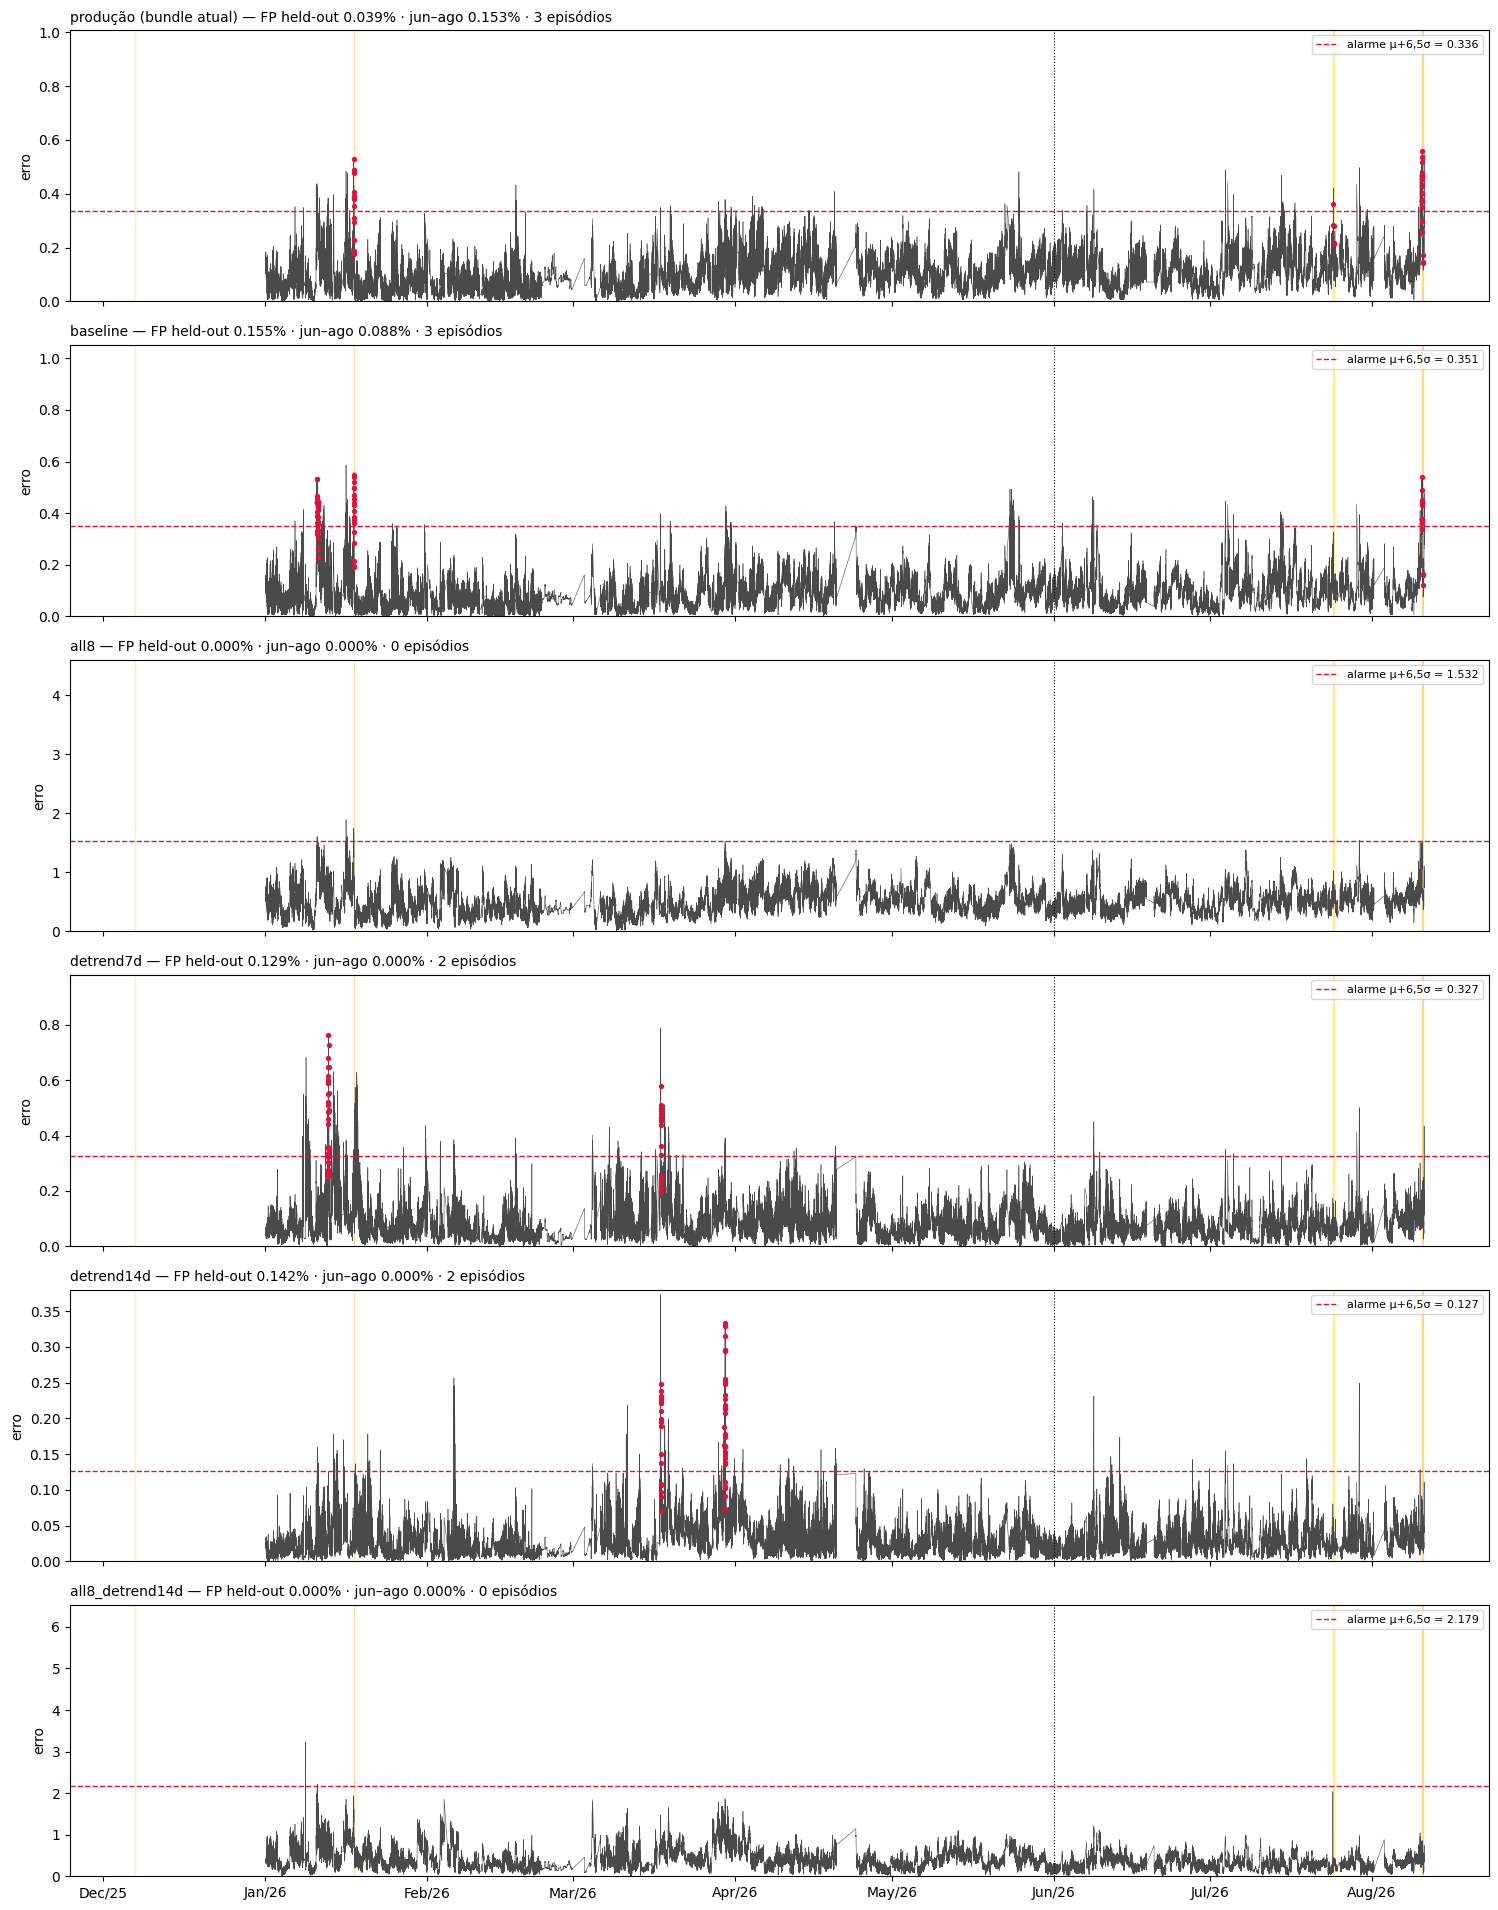

In [5]:
fig, axes = plt.subplots(len(ORDER), 1, figsize=(15, 3.2 * len(ORDER)), sharex=True)
for ax, p in zip(np.atleast_1d(axes), ORDER):
    r = R[p]; e = r["err"][r["err"].index >= TRAIN_END]; fl = r["flags"][r["flags"].index >= TRAIN_END]
    ax.plot(e.index, e.values, lw=.4, color="#4a4a4a"); ax.axhline(r["thr"], color="crimson", lw=1, ls="--", label=f"alarme μ+6,5σ = {r['thr']:.3f}")
    ax.scatter(fl[fl].index, e[fl].values, s=8, color="crimson", zorder=3)
    ax.axvline(HELDOUT_END, color="k", lw=.8, ls=":")
    for k, (a, b) in EPISODES.items(): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="orange" if "ALTA" in k else "gold", alpha=.35)
    ax.set_ylim(0, max(r["thr"] * 3, np.nanpercentile(e.values, 99.9) * 1.1)); ax.set_ylabel("erro")
    ax.set_title(f"{p} — FP held-out {r['fp_heldout']:.3f}% · jun–ago {r['fp_pos']:.3f}% · {r['n_ep_2026']} episódios", loc="left", fontsize=10); ax.legend(loc="upper right", fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b/%y")); plt.tight_layout(); plt.show()

## 4) Falha real de 2022 (série nunca vista) — o modelo de cada preset ainda antecipa?

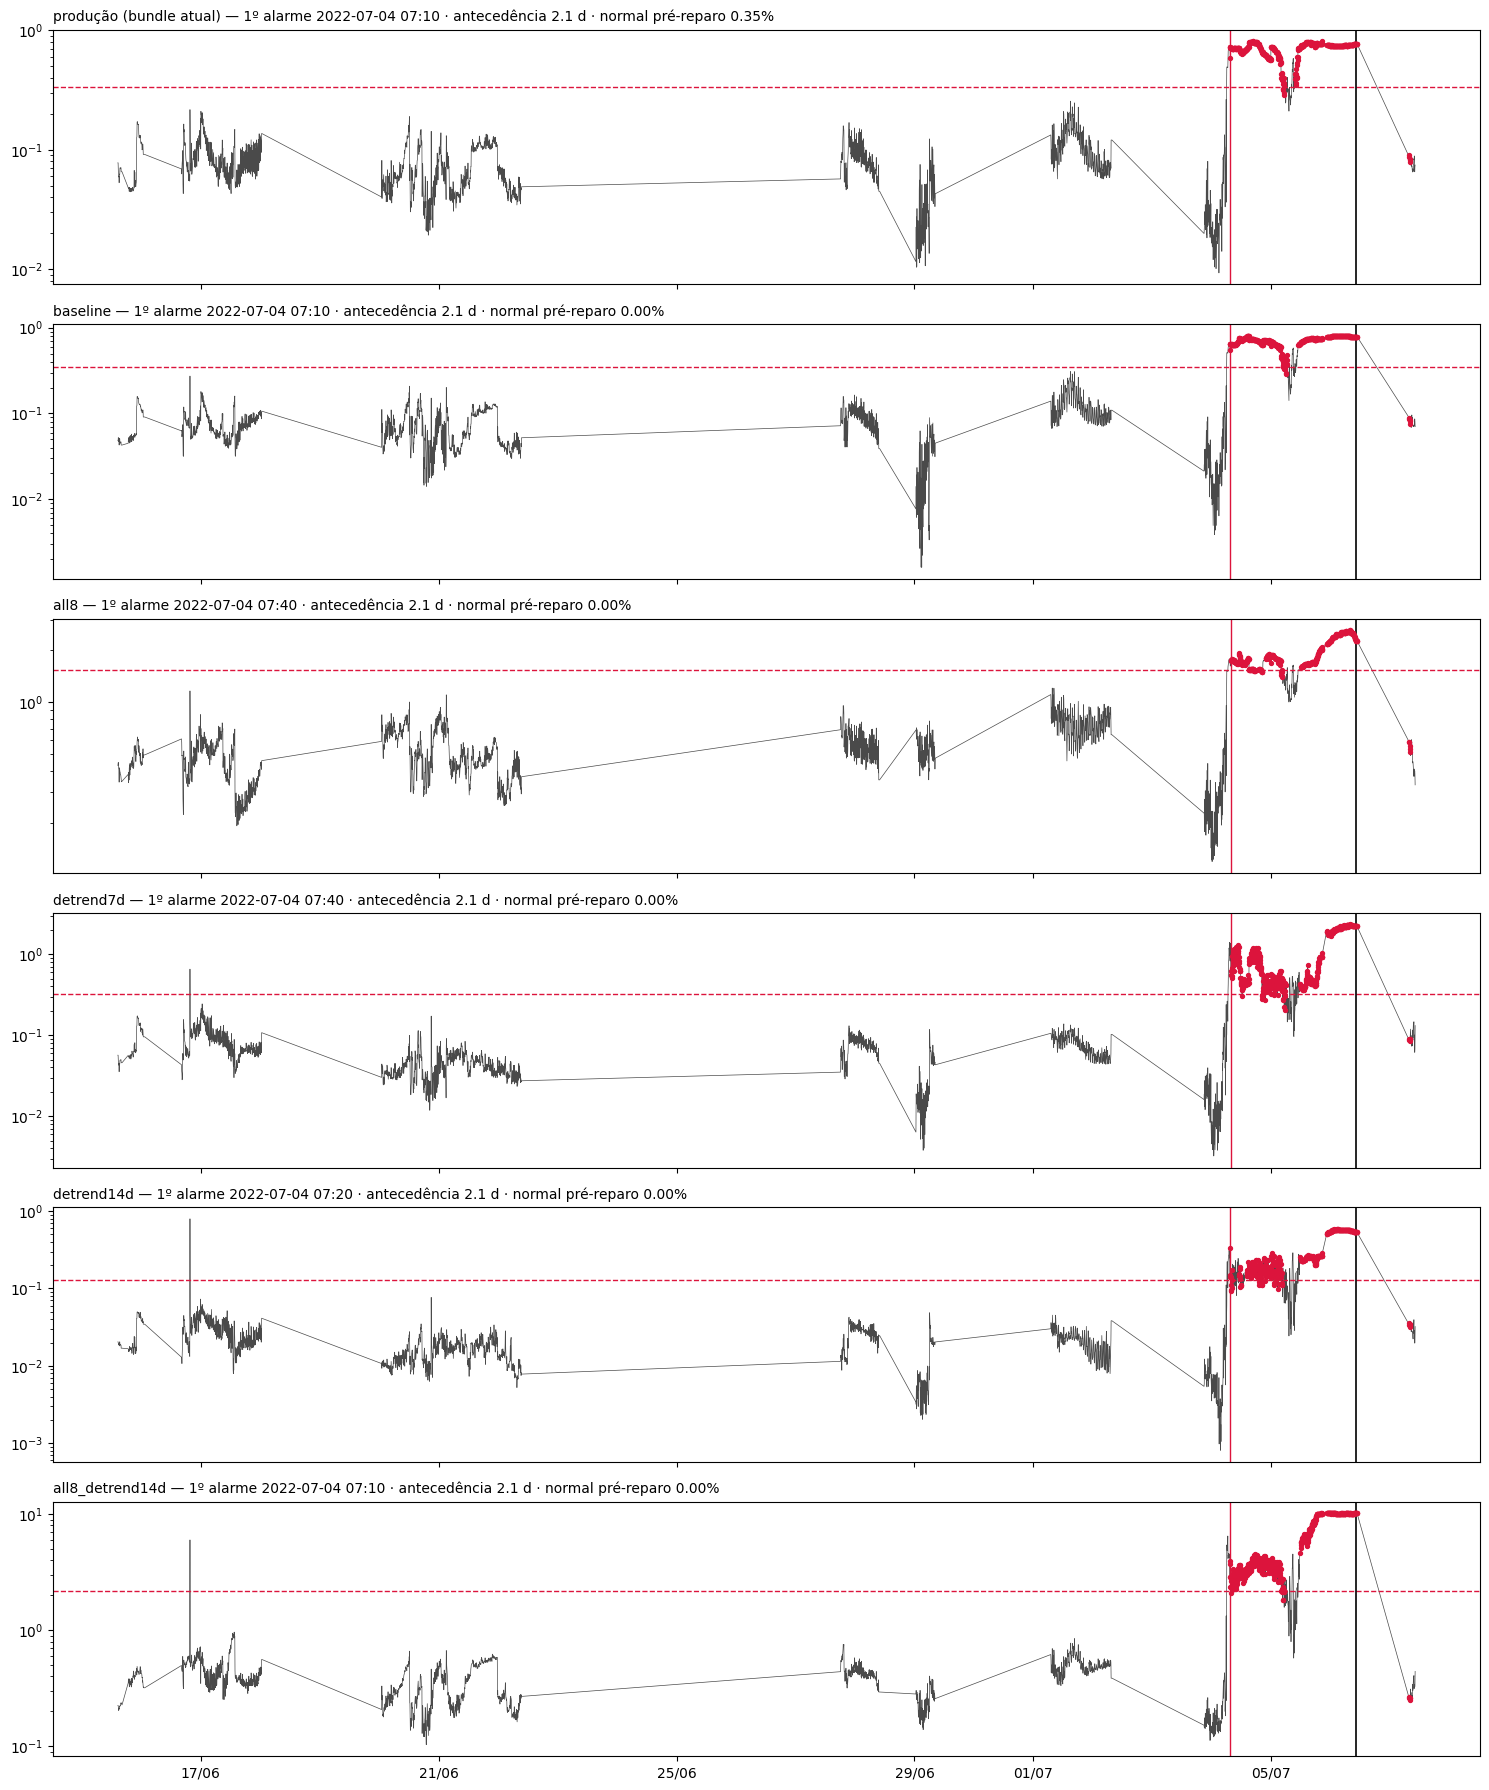

In [6]:
fig, axes = plt.subplots(len(ORDER), 1, figsize=(15, 3.0 * len(ORDER)), sharex=True)
for ax, p in zip(np.atleast_1d(axes), ORDER):
    r = R[p]; e = r["err22"][(r["err22"].index >= "2022-06-15") & (r["err22"].index <= FAILURE_2022 + pd.Timedelta(days=1))]
    f = kofn(r["err22"] > r["thr"]).reindex(e.index).fillna(False)
    ax.plot(e.index, e.values, lw=.5, color="#4a4a4a"); ax.axhline(r["thr"], color="crimson", lw=1, ls="--")
    ax.scatter(f[f].index, e[f].values, s=8, color="crimson", zorder=3); ax.axvline(FAILURE_2022, color="k", lw=1.2)
    if r["first22"] is not None: ax.axvline(r["first22"], color="crimson", lw=1)
    ax.set_yscale("log"); ax.set_title(f"{p} — 1º alarme {str(r['first22'])[:16]} · antecedência {r['lead22']:.1f} d · normal pré-reparo {r['normal22']:.2f}%", loc="left", fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m")); plt.tight_layout(); plt.show()

## 5) Decisão (regra fixada antes dos números)

In [7]:
PREF = ["baseline", "all8", "detrend7d", "detrend14d", "all8_detrend14d"]
passed = [p for p in PREF if p in R and all(criteria(R[p]).values())]
print("Passaram nos 5 critérios:", passed or "nenhum")
if passed:
    # entre os aprovados, o de menor FP fora do treino; empate técnico (<0,01 pp) resolve pela ordem de preferência
    fp = {p: R[p]["fp_heldout"] + R[p]["fp_pos"] for p in passed}; best_fp = min(fp.values())
    winner = next(p for p in PREF if p in fp and fp[p] <= best_fp + 0.01)
    print(f">>> Recomendação: {winner}  (FP fora do treino {fp[winner]:.3f}%; produção = {R['produção (bundle atual)']['fp_heldout'] + R['produção (bundle atual)']['fp_pos']:.3f}%)")
    if winner == "baseline": print("    → nenhuma troca de features se justifica; manter o bundle B-8802B-2025 e as fichas dos 4 episódios.")
    elif winner.startswith("detrend") or "detrend" in winner: print("    → ATENÇÃO deploy: passa a exigir histórico (7–14 d) na entrada + passo remove_slow_trend no simpred_inference.py.")
else:
    print(">>> Nenhum preset supera o bundle atual em todos os critérios → manter B-8802B-2025; os 4 alarmes ficam com a justificativa por episódio.")
for p in ORDER:
    c = criteria(R[p]); print(f"  {p:16s} {''.join('✓' if v else '✗' for v in c.values())}  FP fora-treino={R[p]['fp_heldout'] + R[p]['fp_pos']:.3f}%  lead22={R[p]['lead22']:.1f}d  sint={R[p]['synth100']:.0f}h")

Passaram nos 5 critérios: nenhum
>>> Nenhum preset supera o bundle atual em todos os critérios → manter B-8802B-2025; os 4 alarmes ficam com a justificativa por episódio.
  produção (bundle atual) ✓✓✓✓✓  FP fora-treino=0.193%  lead22=2.1d  sint=22h
  baseline         ✗✓✓✓✓  FP fora-treino=0.243%  lead22=2.1d  sint=24h
  all8             ✓✓✗✗✓  FP fora-treino=0.000%  lead22=2.1d  sint=22h
  detrend7d        ✗✓✓✗✓  FP fora-treino=0.129%  lead22=2.1d  sint=23h
  detrend14d       ✗✓✗✗✓  FP fora-treino=0.142%  lead22=2.1d  sint=9h
  all8_detrend14d  ✓✓✗✗✓  FP fora-treino=0.000%  lead22=2.1d  sint=22h
